In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

RS = 0.001
RCT = 0.001
CDL = 500

tau = RCT*CDL
print(f"Time constant is {tau} seconds\n")

Time constant is 0.5 seconds



In [3]:
def time_domain_model(RS, RCT, CDL, I_signal, t):
    
    dt = t[1] - t[0]
    V_c = np.zeros(len(t))
    V = np.zeros(len(t))
    
    for k in range(len(t) - 1):
        dV_c = (I_signal[k] - V_c[k] / RCT) / CDL
        V_c[k+1] = V_c[k] + dt * dV_c
        V[k] = V_c[k] + I_signal[k] * RS
    
    V[-1] = V_c[-1] + I_signal[-1] * RS
    
    return V, V_c


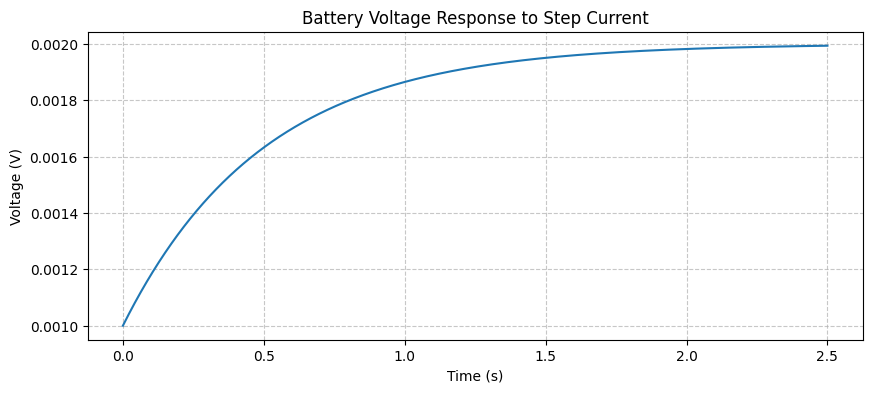

In [4]:
t = np.linspace(0, 5 * tau, 10000)
I_signal = np.ones(len(t))
V, V_c = time_domain_model(RS, RCT, CDL, I_signal, t)

plt.figure(figsize=(10, 4))
plt.plot(t, V)
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Battery Voltage Response to Step Current')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [5]:
f = 1
omega = 2 * np.pi* f
I_t = I_signal * np.sin(omega * t)
V, V_c = time_domain_model(RS, RCT, CDL, I_t, t)

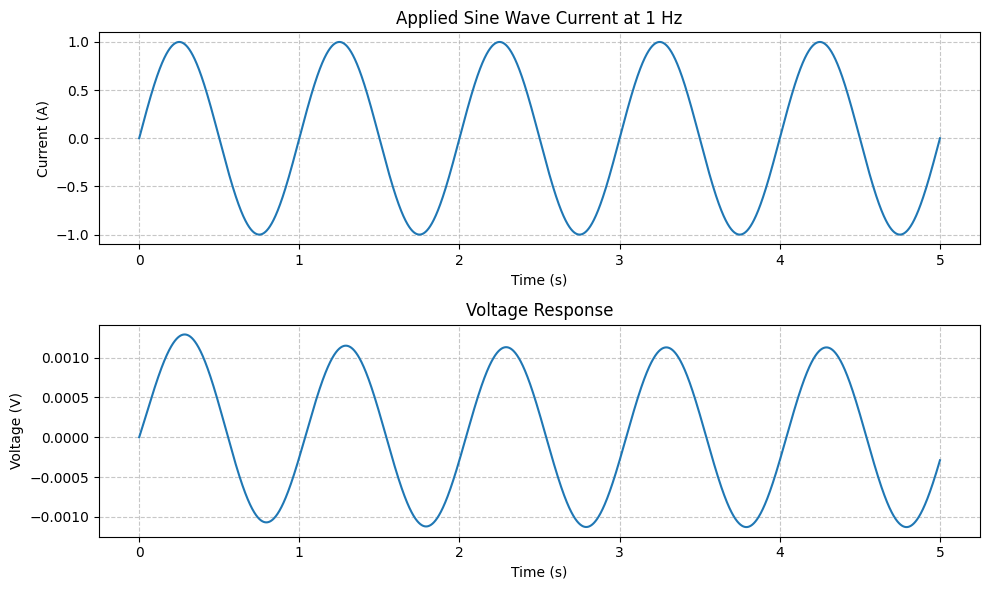

In [6]:
f = 1
I0 = 1
t = np.linspace(0, 5, 10000)
omega = 2 * np.pi * f
I_t = I0 * np.sin(omega * t)

V, V_c = time_domain_model(RS, RCT, CDL, I_t, t)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

ax1.plot(t, I_t)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Current (A)')
ax1.set_title('Applied Sine Wave Current at 1 Hz')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(t, V)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Voltage (V)')
ax2.set_title('Voltage Response')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

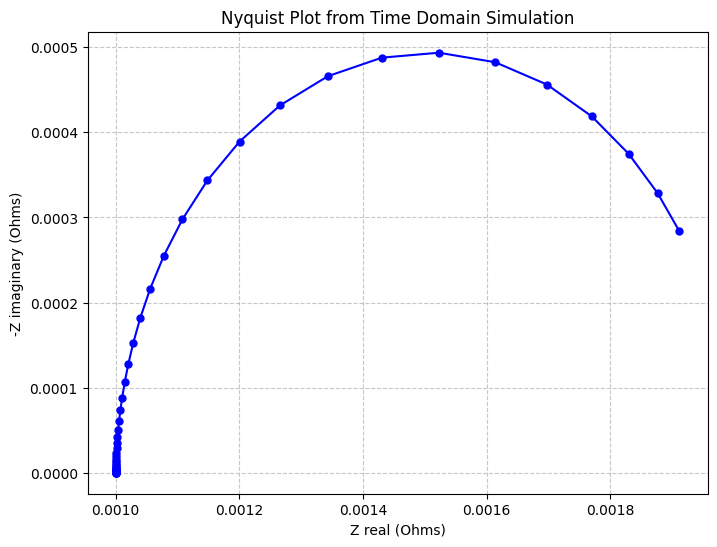

In [7]:
freqs = np.logspace(-1, 3, 50) 

Z_real_sim = []
Z_imag_sim = []

for f in freqs:
    t_sweep = np.linspace(0, 10/f, 10000)
    omega = 2 * np.pi * f
    I_sweep = np.sin(omega * t_sweep)
    
    V_sweep, _ = time_domain_model(RS, RCT, CDL, I_sweep, t_sweep)
    
    N = len(t_sweep)
    V_fft = np.fft.fft(V_sweep)
    I_fft = np.fft.fft(I_sweep)
    
    dt = t_sweep[1] - t_sweep[0]
    freqs_fft = np.fft.fftfreq(N, dt)
    idx = np.argmin(np.abs(freqs_fft - f))
    
    Z = V_fft[idx] / I_fft[idx]
    Z_real_sim.append(Z.real)
    Z_imag_sim.append(-Z.imag)

plt.figure(figsize=(8, 6))
plt.plot(Z_real_sim, Z_imag_sim, 'bo-', markersize=5)
plt.xlabel('Z real (Ohms)')
plt.ylabel('-Z imaginary (Ohms)')
plt.title('Nyquist Plot from Time Domain Simulation')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

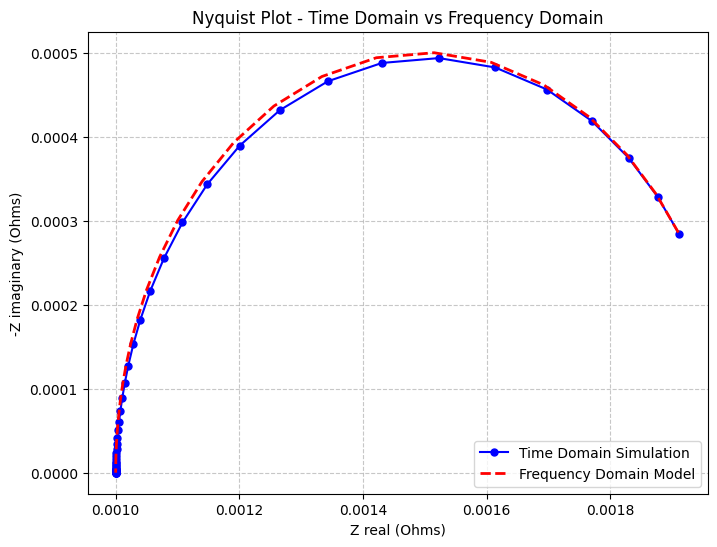

In [8]:
def freq_domain_model(freqs, RS, RCT, CDL):
    omega = 2 * np.pi * freqs
    Z_cdl = 1 / (1j * omega * CDL)
    Z_parallel = (RCT * Z_cdl) / (RCT + Z_cdl)
    return RS + Z_parallel

# Calculate frequency domain model
Z_freq = freq_domain_model(freqs, RS, RCT, CDL)

# Plot both on same graph
plt.figure(figsize=(8, 6))
plt.plot(Z_real_sim, Z_imag_sim, 'bo-', markersize=5, label='Time Domain Simulation')
plt.plot(Z_freq.real, -Z_freq.imag, 'r--', linewidth=2, label='Frequency Domain Model')
plt.xlabel('Z real (Ohms)')
plt.ylabel('-Z imaginary (Ohms)')
plt.title('Nyquist Plot - Time Domain vs Frequency Domain')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()